In [2]:
from keras.applications.vgg16 import preprocess_input
from keras.models import Model
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import cv2
from keras.preprocessing import image
from keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

In [23]:
class FaceRecognition(BaseEstimator, TransformerMixin):
    def __init__(self):
        base_model = VGG16(weights='imagenet')
        self.model = Model(inputs=base_model.input, outputs=base_model.get_layer('fc2').output)

    def face_cascade_function(self, X):
        face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

        img = cv2.imread(X)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.1, 4)

        for (x, y, w, h) in faces:
            face_roi = img[y:y+h, x:x+w]  # извлекаем ROI лица для дальнейшего анализа

        face_img = cv2.resize(face_roi, (224, 224))
        x = img_to_array(face_img)
        x = np.expand_dims(x, axis=0)
        x = preprocess_input(x)

        hardy_features = self.model.predict(x)
        saved_features = np.save('Alex_features_face_cascade.npy', hardy_features)

        return saved_features

    def get_face_features(self, Y):
        face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

        img = cv2.imread(Y)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.1, 4)
        for (x, y, w, h) in faces:
            face_roi = img[y:y+h, x:x+w]

        face_img = cv2.resize(face_roi, (224, 224))
        x = img_to_array(face_img)
        x = np.expand_dims(x, axis=0)
        x = preprocess_input(x)
        features = self.model.predict(x)
        return features

    def is_match(self, Y, saved_features, threshold=80):

        print(Y)
        print(saved_features)

        distance = np.linalg.norm(saved_features - Y)
        return distance < threshold

    def display_image_with_results(self, Y, saved_features):
        img = cv2.imread(Y)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
        faces = face_cascade.detectMultiScale(gray, 1.1, 4)

        features = self.get_face_features(Y)

        for (x, y, w, h) in faces:
            if self.is_match(features, saved_features):
                cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
                cv2.putText(img, "Alex", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
            else:
                cv2.rectangle(img, (x, y), (x+w, y+h), (0, 0, 255), 2)
                cv2.putText(img, "Not Alex", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)

        from matplotlib import pyplot as plt
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.imshow(img)
        plt.axis('off')

        return plt.show()

In [24]:
pipe = Pipeline(steps=[
    ('model', FaceRecognition())
])

pipe.named_steps['model'].face_cascade_function('1.png')
saved_features = np.load('Alex_features_face_cascade.npy')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
[[0.        0.        1.1949241 ... 0.        0.        1.4396634]]
[[0.         0.         0.         ... 0.         0.         0.00988841]]


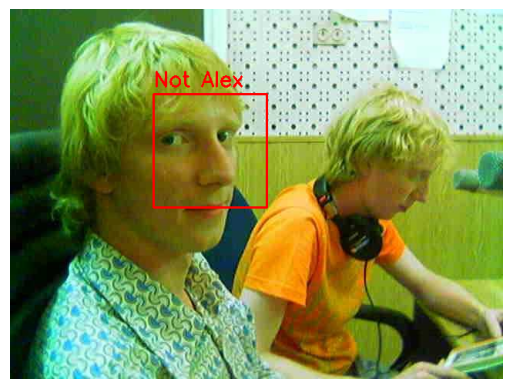

In [25]:
pipe.named_steps['model'].display_image_with_results('6.png', saved_features)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[[0. 0. 0. ... 0. 0. 0.]]
[[0.         0.         0.         ... 0.         0.         0.00988841]]
[[0. 0. 0. ... 0. 0. 0.]]
[[0.         0.         0.         ... 0.         0.         0.00988841]]


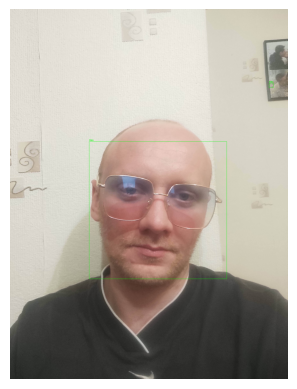

In [26]:
pipe.named_steps['model'].display_image_with_results('4.jpg', saved_features)